ATTENTION : Il faut soit avoir généré un embed, soit en avoir téléchargé un, soit utiliser ce script depuis colab !

In [7]:
!pip install random-fourier-features-pytorch
!pip install geopy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)

   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]



In [1]:
from src.cross.model_cross import MixedEncoder
from src.embed_database import load_database, get_closest, visualize_geo
from src.dataset import get_images_pos
import cv2
import torch
from geopy.geocoders import Nominatim
import time

In [2]:
#On récupère la device, cuda idéalement !
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
#On charge la base de données des embeddings !
#C'est un dict de format : {"ids" : list[Int], "elems" : les embeddings de dimension 512}
db = load_database("embeddings_db.pt")

print("Nombre d'éléments dans la DB :", len(db["ids"]))

#On récupère les positions pures des éléments de la DB
pos = get_images_pos("./gen_fr/coordinates_france.json")

print("Nombre de positions chargées : ", len(pos))

Nombre d'éléments dans la DB : 120800
Nombre de positions chargées :  152450


Affichage de 120800 points géographiques.


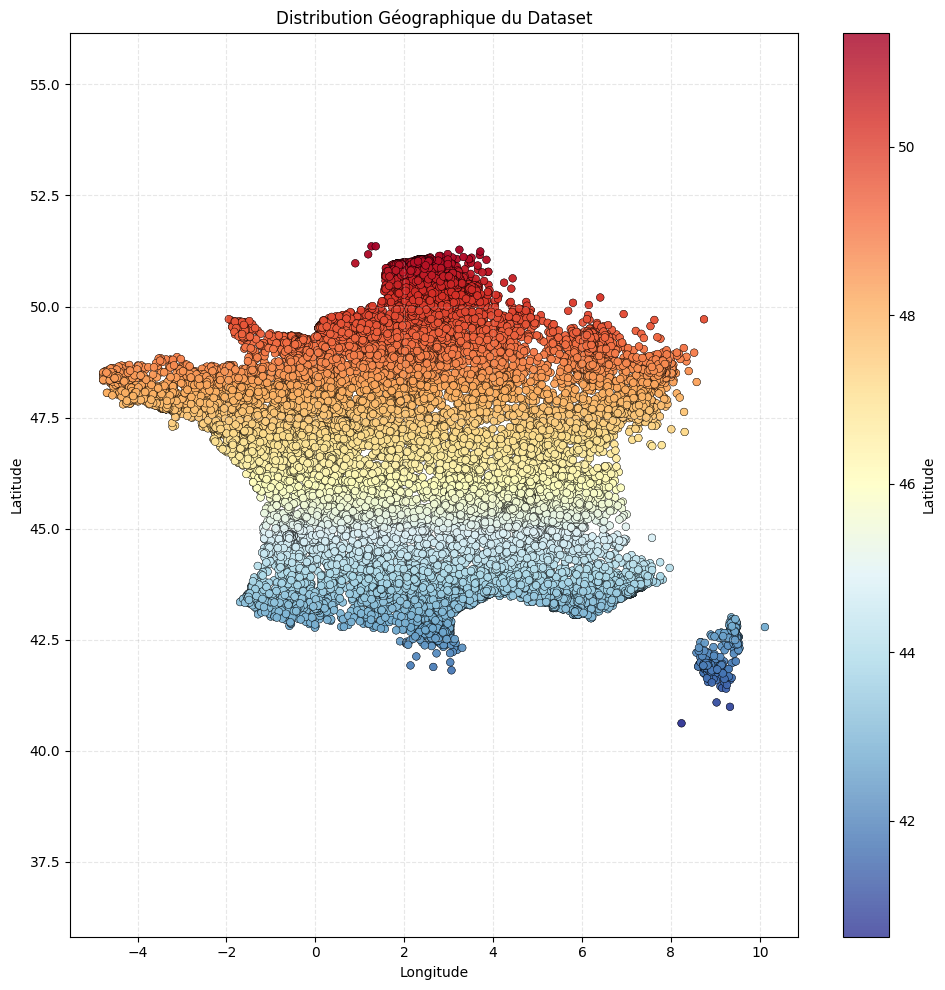

In [4]:
#On visualise à quoi ressemble la BD
visualize_geo(db, pos_dict=pos)

In [ ]:
#On charge l'image à tester
img = cv2.imread("test_img_2.png", cv2.IMREAD_COLOR)

#On charge le modèle
model = MixedEncoder().to(DEVICE)
model.load_state_dict(torch.load("final_paris.pt"))

Using cache found in C:\Users\Utilisateur/.cache\torch\hub\facebookresearch_dinov2_main


<All keys matched successfully>

In [22]:
geolocator = Nominatim(user_agent="geo_guessr_student_project_fr")

results = get_closest(db, img, model, k=10)

print(f"\nANALYSE DE LA POSITION : TOP {len(results)} RÉSULTATS\n")
print("="*60)
for rank, (idx, score) in enumerate(results):
    idx = int(idx)

    #print(pos[idx])
    
    try:
        lat, lon = pos[idx]
        
        try:
            location = geolocator.reverse(f"{lat}, {lon}", language='fr', exactly_one=True)
            address = location.address if location else "Adresse inconnue"
        except Exception as e:
            address = f"Erreur de géocodage : {e}"

        print(f"Rang {rank+1}")
        print(f"Similarité : {score:.4f} (Confiance)")
        print(f"GPS        : {lat:.6f}, {lon:.6f}")
        print(f"Adresse    : {address}")
        
        # Lien Google Maps cliquable pour frimer
        gmaps_link = f"https://www.google.com/maps/search/?api=1&query={lat},{lon}"
        print(f"Google Maps: {gmaps_link}")
        print("-" * 60)
        
        time.sleep(1)
        
    except KeyError:
        print(f"ID {idx} non trouvé dans le fichier JSON des coordonnées.")


ANALYSE DE LA POSITION : TOP 10 RÉSULTATS

Rang 1
Similarité : 0.3806 (Confiance)
GPS        : 43.714827, 7.285342
Adresse    : Avenue Denis Séméria, Saint-Roch, Cité Fracchia, Nice, Alpes-Maritimes, Provence-Alpes-Côte d'Azur, France métropolitaine, 06300, France
Google Maps: https://www.google.com/maps/search/?api=1&query=43.71482715827847,7.28534183387216
------------------------------------------------------------
Rang 2
Similarité : 0.3806 (Confiance)
GPS        : 43.714827, 7.285342
Adresse    : Avenue Denis Séméria, Saint-Roch, Cité Fracchia, Nice, Alpes-Maritimes, Provence-Alpes-Côte d'Azur, France métropolitaine, 06300, France
Google Maps: https://www.google.com/maps/search/?api=1&query=43.71482715827847,7.28534183387216
------------------------------------------------------------
Rang 3
Similarité : 0.3806 (Confiance)
GPS        : 43.692875, 7.284698
Adresse    : Bassin des Amiraux, Digue, Le Port, Carabacel, Nice, Alpes-Maritimes, Provence-Alpes-Côte d'Azur, France métropol